In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np

def precision(y_true, y_pred, normalize=True, sample_weight=None):
    pre_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_prec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_prec = 1
            pre_list.append(tmp_prec)
        elif len(set_pred) > 0:
            tmp_prec = len(set_true.intersection(set_pred))/\
                    float(len(set_pred))
            pre_list.append(tmp_prec)
        else:
            None
    return np.mean(pre_list)

def recall(y_true, y_pred, normalize=True, sample_weight=None):
    rec_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_rec = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_rec = 1
        else:
            tmp_rec = len(set_true.intersection(set_pred))/\
                    float(len(set_true))
        rec_list.append(tmp_rec)
    return np.mean(rec_list)

def f_score(y_true, y_pred, normalize=True, sample_weight=None):
    acc_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_a = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_a = 1
        else:
            tmp_a = (2*len(set_true.intersection(set_pred)))/\
                    float( len(set_true) + len(set_pred))
        acc_list.append(tmp_a)
    return np.mean(acc_list)

In [ ]:
train_path = "/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/train_data_bp1.csv"
test_path = "/content/gdrive/My Drive/Transformer_positional_embedding/CAFA3/bp/test_data_bp1.csv"

In [ ]:
import math
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from keras import backend as K
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import keras
tf.random.set_seed(7)

In [ ]:
from csv import writer

def test_segment(filename, low, up):
    myFile = open(filename, 'w', newline = '')
    with myFile:
        csv_writer = writer(myFile)
        for j, row in enumerate(seqData):
            segment = [ ]
            if(len(row) > low and len(row) < up):
                segment.append(row)
                for item in label[j]:
                    segment.append(item)
                csv_writer.writerow(segment)
    myFile.close()

dataframe = pd.read_csv(test_path, header=None)
dataset = dataframe.values
seqData = dataset[:,0]
label = dataset[:,1:len(dataset[0])]
print('Original Dataset Size : %s' %len(dataset))
test_segment('testData200.csv', 0, 201)
test_segment('testData500.csv', 200, 501)
test_segment('testData1000.csv', 500, 1001)
test_segment('testData16000.csv', 1000, 16000)

Original Dataset Size : 2392


In [ ]:
def segment(dataset, label, seg_size, overlap):
    print("Non-overlapping Region: %s" %overlap)
    print("Segment Size: %s" %seg_size)

    seq_data, label_data = [], []
    for j, row in enumerate(dataset):
        if(len(row) < 2001):
            pos = math.ceil(len(row)/overlap)
            if(pos < math.ceil(seg_size/overlap)):
                pos = math.ceil(seg_size/overlap)
            for itr in range(pos - math.ceil(seg_size/overlap) + 1):
                init = itr * overlap
                if(len(row[init : init + seg_size]) > 40):
                    seq_data.append(row[init : init + seg_size])
                    label_data.append(label[j])
    return seq_data, label_data

dataframe = pd.read_csv(train_path, header=None)
dataset = dataframe.values
print('Original Dataset Size : %s' %len(dataset))
X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])]
del dataframe, dataset
print(X.shape, Y.shape)

# Preparing For Training
segmentSize = 100
nonOL = segmentSize - 50
SEG = str(segmentSize)

X, Y = segment(X, Y, segmentSize, nonOL)
nb_of_cls = len(Y[0])

#Split the dataset
x_tr, x_val, y_tr, y_val = train_test_split(X, Y, test_size = 0.1, random_state = 42)

y_train = np.array(y_tr, dtype=None)
y_validate = np.array(y_val, dtype=None)
print(len(x_tr), len(x_val))
print(y_train.shape, y_validate.shape)

del y_tr, y_val

Original Dataset Size : 53500
(53500,) (53500, 3992)
Non-overlapping Region: 50
Segment Size: 100
447228 49692
(447228, 3992) (49692, 3992)


In [ ]:
def dictionary(chunk_size):
    dataframe = pd.read_csv(train_path, header=None)
    dataset = dataframe.values
    del dataframe

    seq_dataset = dataset[:,0]
    print('Creating Dictionary:')
    dict = {}
    j = 0
    for row in seq_dataset:
        for i in range(len(row) - chunk_size + 1):
            key = row[i:i + chunk_size]
            if key not in dict:
                dict[key] = j
                j = j + 1
    del dataset, seq_dataset
    return(dict)

def nGram(dataset, chunk_size, dictI):
    dict1 = list()
    for j, row in enumerate(dataset):
        string = row
        dict2 = list()
        for i in range(len(string) - chunk_size + 1):
            try:
                dict2.append(dictI[string[i:i + chunk_size]])
            except:
                None
        dict1.append(dict2)
    return(dict1)

def pChemical(dataset, max_len):
    def normalize_attribute(aa_prop):
        max_item = max(list(aa_prop.values())) + 1
        min_item = min(list(aa_prop.values())) - 1
        for key in aa_prop.keys():
            aa_prop[key] = (aa_prop[key] - min_item) / (max_item - min_item)

    encoded_seg_data = []
    aa_side_chain_mass = {'A':89.079,  'R':174.188, 'N':132.104, 'D':133.089, 'C':121.145,
                          'Q':146.131, 'E':147.116, 'G':75.052,  'H':155.141, 'I':131.160,
                          'L':131.160, 'K':146.17,  'M':149.199, 'F':165.177, 'P':115.177,
                          'S':105.078, 'T':119.105, 'W':204.213, 'Y':181.176, 'V':117.133}

    aa_hydrophobic_value = {'A':1.8,  'R':-4.5,  'N':-3.5,  'D':-3.5,  'C':2.5,
                            'Q':-3.5, 'E':-3.5,  'G':-0.4,  'H':-3.2,  'I':4.5,
                            'L':3.8,  'K':-3.9,  'M':1.9,   'F':2.8,   'P':-1.6,
                            'S':-0.8, 'T':-0.7,  'W':-0.9,  'Y':-1.3,  'V':4.2}

    aa_hydrophilic_value = {'A':-0.5, 'R':3.0,   'N':0.2,   'D':3.0,   'C':-1.0,
                            'Q':0.2,  'E':3.0,   'G':0.0,   'H':-0.5,  'I':-1.8,
                            'L':-1.8, 'K':3.0,   'M':-1.3,  'F':-2.5,  'P':0.0,
                            'S':0.3,  'T':-0.4,  'W':-3.4,  'Y':-2.3,  'V':-1.5}

    aa_van_der_walls_value = {'A':67, 'R':148,   'N':96,   'D':91,   'C':86,
                            'Q':114,  'E':109,   'G':48,   'H':118,  'I':124,
                            'L':124, 'K':135,   'M':124,  'F':135,  'P':90,
                            'S':90,  'T':93,  'W':163,  'Y':141,  'V':105}

    normalize_attribute(aa_side_chain_mass)
    normalize_attribute(aa_hydrophobic_value)
    normalize_attribute(aa_hydrophilic_value)
    normalize_attribute(aa_van_der_walls_value)
    #print(aa_side_chain_mass, aa_hydrophobic_value, aa_hydrophilic_value)

    for j, row in enumerate(dataset):
        segMer = []
        for i in range(max_len - len(row)):
              encode = [0.0]*4
              segMer.append(encode)
        for i in range(len(row)):
            try:
              encode = [0.0]*4
              encode[0] = aa_side_chain_mass[row[i]]
              encode[1] = aa_hydrophobic_value[row[i]]
              encode[2] = aa_hydrophilic_value[row[i]]
              encode[3] = aa_van_der_walls_value[row[i]]
              segMer.append(encode)
            except:
              encode = [0.0]*4
              segMer.append(encode)
        encoded_seg_data.append((np.array(segMer)))
    return((np.array(encoded_seg_data)))

# CREATING DICTIONARY
chunkSize = 4
dict_Prop = dictionary(chunkSize)
max_seq_len = segmentSize - chunkSize + 1

#CREATING N-GRAM REPRESENTATION
x_train_gram = nGram(x_tr, chunkSize, dict_Prop)
x_validate_gram = nGram(x_val, chunkSize, dict_Prop)

# truncate and pad input sequences
x_train_gram = sequence.pad_sequences(x_train_gram, maxlen=max_seq_len)
x_validate_gram = sequence.pad_sequences(x_validate_gram, maxlen=max_seq_len)
print(x_train_gram.shape, x_validate_gram.shape)

#CREATING PHYSICOCHEMICAL REPRESENTATION
x_train_phy = pChemical(x_tr, segmentSize)
x_validate_phy = pChemical(x_val, segmentSize)
print(x_train_phy.shape, x_validate_phy.shape)
del x_tr, x_val

Creating Dictionary:
(447228, 97) (49692, 97)
(447228, 100, 4) (49692, 100, 4)


In [ ]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, seq_len, embed_dim, w_size, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.w_size = w_size
        if embed_dim % num_heads != 0:
            raise ValueError(f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def create_window_mask(self, seq_len, w_size):
        seq_len = 48
        mat = np.ones((seq_len, seq_len))
        for index in range(seq_len):
            for j in range(max(0, index - w_size), min(index + w_size + 1, seq_len)):
                mat[index][j] = 0
        tensor = tf.convert_to_tensor(mat)
        return tf.cast(tensor, tf.bool)

    def attention(self, query, key, value, mask):
        score = tf.matmul(query, key, transpose_b=True)                         # Calculate attention.
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)

        # Implement Masking.
        if self.w_size is not None and mask is not None:
            win_mask = self.create_window_mask(self.seq_len, self.w_size)        # Compute window mask.
            int_mask = tf.math.logical_or(tf.cast(mask[0], tf.bool), win_mask)   # Combine pad mask and window mask.
            int_mask = tf.math.logical_or(tf.cast(mask[1], tf.bool), tf.cast(int_mask, tf.bool))
            final_mask = tf.cast(int_mask, tf.float32)
            scaled_score += (final_mask * -1e5)
        elif mask is not None:                                                     # add the mask to the scaled tensor.
            final_mask = mask[0]
            scaled_score += (final_mask * -1e5)                                    # mask: Float tensor (..., seq_len_q, seq_len_k).

        weights = tf.nn.softmax(scaled_score, axis=-1)
        max_wt = tf.reduce_max(weights, axis = -1)
        scaled_weights = tf.divide(weights, max_wt[:,:,:,tf.newaxis])             # Scaled SOFTMAX
        reverse_final_mask = 1.0 - final_mask
        scaled_weights = tf.multiply(scaled_weights, reverse_final_mask) + 0.001  # Re-apply mask
        output = tf.matmul(scaled_weights, value)
        return output, scaled_weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, mask):
        # x.shape = [batch_size, seq_len, embedding_dim]
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)                                        # (batch_size, seq_len, embed_dim)
        key = self.key_dense(inputs)                                            # (batch_size, seq_len, embed_dim)
        value = self.value_dense(inputs)                                        # (batch_size, seq_len, embed_dim)
        query = self.separate_heads(query, batch_size)                          # (batch_size, num_heads, seq_len, projection_dim)
        key = self.separate_heads(key, batch_size)                              # (batch_size, num_heads, seq_len, projection_dim)
        value = self.separate_heads(value, batch_size)                          # (batch_size, num_heads, seq_len, projection_dim)
        attention, weights = self.attention(query, key, value, mask)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])                             # (batch_size, seq_len, num_heads, projection_dim)
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))         # (batch_size, seq_len, embed_dim)
        output = self.combine_heads(concat_attention)                                      # (batch_size, seq_len, embed_dim)
        return output, weights

class TransformerBlock(layers.Layer):
    def __init__(self, seq_len, embed_dim, num_heads, ff_dim, w_size, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.w_size = w_size
        self.att = MultiHeadSelfAttention(seq_len, embed_dim, w_size, num_heads)          # Sub-layer 1
        self.ffn = keras.Sequential([layers.Dense(ff_dim, kernel_initializer='normal', activation="relu"),    # Sub-layer 2
                                     layers.Dense(embed_dim, kernel_initializer='normal'),])                  # Two linear transformations with ReLU activation in between.
        #self.ffn = keras.Sequential([KANLinear(ff_dim, base_activation="relu"),                               # Sub-layer 2
        #                             layers.Dense(embed_dim, kernel_initializer='normal'),])                  # Two linear transformations with ReLU activation in between.
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate=0.2)
        self.dropout2 = layers.Dropout(rate=0.2)

    def call(self, inputs, mask, training=True):                                           # Main transformer block
        attn_output, attn_wt = self.att(inputs, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output), attn_wt

    def get_config(self):
        config = super().get_config().copy()
        config.update({'embed_dim': self.embed_dim, 'num_heads': self.num_heads, 'ff_dim': self.ff_dim,
                       'seq_len': self.seq_len, 'w_size': self.w_size})
        return config

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, emded_dim, **kwargs):
        super(TokenAndPositionEmbedding, self).__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.emded_dim = emded_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=emded_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=emded_dim)
        self.dropout1 = layers.Dropout(rate=0.3)
        self.dropout2 = layers.Dropout(rate=0.3)

    def create_padding_mask(self, seq, batch_size):
        index = [[i] for i in range(0, max_seq_len - 1, 2)]     # Captures the alternate indices to implement sequence shorting.
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)    # add extra dimensions to add the padding to the attention logits.
        seq = tf.reshape(tf.gather(seq, indices = index, axis = -1), [batch_size, len(index)])     # Helps extract the alternate values from the seq
        return seq[:, tf.newaxis, tf.newaxis, :], seq[:, tf.newaxis, :, tf.newaxis]
        # return (batch_size, 1, 1, seq_len), (batch_size, 1, seq_len, 1)

    def call(self, x, training=True):
        maxlen = tf.shape(x)[-1]
        batch_size = tf.shape(x)[0]
        padding_mask = self.create_padding_mask(x, batch_size)

        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        positions = self.dropout1(positions, training=training)
        x = self.token_emb(x)
        x = self.dropout2(x, training=training)
        return x + positions, padding_mask

    def get_config(self):
        config = super().get_config().copy()
        config.update({'maxlen': self.maxlen, 'vocab_size': self.vocab_size,'emded_dim': self.emded_dim,})
        return config

def create_rec_model1(top_words, seq_len, o_dim):
    embedding_vecor_length = 80          # Embedding size for each token
    num_heads = 4                        # Number of attention heads
    ff_dim = 128                         # Hidden layer size in feed forward network inside transformer

    # N-GRAM INPUT REPRESENTATION
    inp_gram = layers.Input(shape=(seq_len,))
    embedding_layer = TokenAndPositionEmbedding(seq_len, top_words, embedding_vecor_length)
    x_gram, pad_mask = embedding_layer(inp_gram)
    x_gram = layers.Dropout(0.3)(x_gram)
    x = layers.AveragePooling1D(pool_size = 2, strides = 2)(x_gram)                             # Sequence Shorting

    transformer_block1 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, 12)       # 13 - 1   ---------> 25 %
    x1, attn_score1 = transformer_block1(x, pad_mask)

    transformer_block2 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, 24)       # 25 - 1   ---------> 50 %
    x2, attn_score2 = transformer_block2(x, pad_mask)

    transformer_block3 = TransformerBlock(seq_len, embedding_vecor_length, num_heads, ff_dim, seq_len)  # 50      ---------> Complete
    x3, attn_score3 = transformer_block3(x, pad_mask)

    # PHYSICOCHEMICAL INPUT REPRESENTATION
    inp_phy = layers.Input(shape=(segmentSize, 4), dtype=np.float32)
    x_phy = layers.Conv1D(filters = 128, kernel_size = 3, activation = 'relu', padding = "same")(inp_phy)
    x_phy = layers.Conv1D(filters = 64, kernel_size = 4, activation = 'relu')(x_phy)
    x_phy = layers.BatchNormalization()(x_phy)
    x_phy = layers.AveragePooling1D(pool_size = 2, strides = 2)(x_phy)                             # Sequence Shorting

    transformer_block_phy = TransformerBlock(seq_len, 64, num_heads, ff_dim, seq_len)  # 50      ---------> Complete
    x_phy, attn_score_phy = transformer_block_phy(x_phy, pad_mask)

    x = layers.Concatenate(axis = -1)([x1, x2, x3, x_phy])

    # compute importance for each step
    attention1 = layers.Dense(1, activation='tanh')(x)
    attention1 = layers.Flatten()(attention1)
    attention1 = layers.Activation('softmax')(attention1)

    attention2 = layers.Dense(1, activation='tanh')(x)
    attention2 = layers.Flatten()(attention2)
    attention2 = layers.Activation('softmax')(attention2)

    attention3 = layers.Dense(1, activation='tanh')(x)
    attention3 = layers.Flatten()(attention3)
    attention3 = layers.Activation('softmax')(attention3)

    attention = layers.Add()([attention1,attention2,attention3])
    attention = layers.RepeatVector(304)(attention)
    attention = layers.Permute([2, 1])(attention)

    sent_representation = layers.Multiply()([x, attention])

    # Sum over axis=1: (None, 304)
    def sum_over_time(x):
        return tf.reduce_sum(x, axis=1)

    sent_representation = layers.Lambda(sum_over_time, output_shape=(304,))(sent_representation)
    #sent_representation = layers.Lambda(lambda xin: keras.ops.sum(xin, axis=1))(sent_representation)

    x = layers.Dropout(0.3)(sent_representation)
    outputs = layers.Dense(o_dim, kernel_initializer='normal', activation='sigmoid')(x)

    r_model = keras.Model(inputs=[inp_gram, inp_phy], outputs=[outputs])

    adam = keras.optimizers.Adam(learning_rate=0.0008)
    r_model.compile(loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=3.0), optimizer=adam, metrics=['binary_accuracy'])
    return r_model

# Create & Compile the model
model_recc = create_rec_model1(len(dict_Prop), max_seq_len, nb_of_cls)
print(model_recc.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 100, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 97)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 128)  │      1,664 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ [(None, 97, 80),  │ 12,887,200 │ input_layer[0][0] │
│ (TokenAndPositionE… │ (None, 1, 1, 48), │            │                   │
│                     │ (None, 1, 48, 1)] │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 64)    │     32,832 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 97, 80)    │          0 │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 97, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 48, 80)    │          0 │ dropout_2[0][0]   │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 48, 64)    │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ [(None, 48, 80),  │     46,928 │ average_pooling1… │
│ (TransformerBlock)  │ (None, 4, 48,     │            │ token_and_positi… │
│                     │ 48)]              │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ [(None, 48, 80),  │     46,928 │ average_pooling1… │
│ (TransformerBlock)  │ (None, 4, 48,     │            │ token_and_positi… │
│                     │ 48)]              │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ [(None, 48, 80),  │     46,928 │ average_pooling1… │
│ (TransformerBlock)  │ (None, 4, 48,     │            │ token_and_positi… │
│                     │ 48)]              │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ [(None, 48, 64),  │     33,472 │ average_pooling1… │
│ (TransformerBlock)  │ (None, 4, 48,     │            │ token_and_positi… │
│                     │ 48)]              │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 304)   │          0 │ transformer_bloc… │
│ (Concatenate)       │                   │            │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 48, 1)     │        305 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 48, 1)     │        305 │ concatenate[0][0

 Total params: 14,314,683 (54.61 MB)

 Trainable params: 14,314,555 (54.61 MB)

 Non-trainable params: 128 (512.00 B)

None


In [ ]:
# Train
early_stopping_monitor1 = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, verbose = 1)
history = model_recc.fit([x_train_gram, x_train_phy], y_train.astype(None),
          validation_data = ([x_validate_gram, x_validate_phy], y_validate.astype(None)),
          epochs = 1000,
          batch_size = 150,
          callbacks=[early_stopping_monitor1],
          verbose=1)

del y_train, y_validate

Epoch 1/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 152s 31ms/step - binary_accuracy: 0.9845 - loss: 0.0109 - val_binary_accuracy: 0.9867 - val_loss: 0.0080
Epoch 2/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - binary_accuracy: 0.9869 - loss: 0.0076 - val_binary_accuracy: 0.9871 - val_loss: 0.0074
Epoch 3/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - binary_accuracy: 0.9874 - loss: 0.0068 - val_binary_accuracy: 0.9874 - val_loss: 0.0070
Epoch 4/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - binary_accuracy: 0.9879 - loss: 0.0062 - val_binary_accuracy: 0.9875 - val_loss: 0.0068
Epoch 5/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - binary_accuracy: 0.9883 - loss: 0.0058 - val_binary_accuracy: 0.9875 - val_loss: 0.0069
Epoch 6/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - binary_accuracy: 0.9886 - loss: 0.0055 - val_binary_accuracy: 0.9876 - val_loss: 0.0072
Epoch 7/1000
2982/2982 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - binary_accuracy: 0.9889 - loss: 0.0053 - val_binary_accur

In [ ]:
from keras.models import load_model

def cls_predict(pred, normalize=True, sample_weight=None):
    s_mean = np.mean(pred, axis=0)
    #m = max(s_mean)
    #s_mean = (s_mean/m)
    return(list(s_mean))

def final_model(filename):
    print('Extracting features based on LSTM model...... ')
    dataframe2 = pd.read_csv(filename, header=None)
    dataset2 = dataframe2.values
    overlap = 50
    X_test = dataset2[:,0]
    Y_test = dataset2[:,1:len(dataset2[0])]

    min_pos = math.ceil(segmentSize / overlap)
    all_segments = []
    segment_counts = []   # keeps track of which segments belong to which sequence

    # --------- Segment generation ----------
    for row in X_test:
        pos = max(math.ceil(len(row) / overlap), min_pos)

        segments = []
        for itr in range(pos - min_pos + 1):
            init = itr * overlap
            segments.append(row[init:init + segmentSize])

        segment_counts.append(len(segments))
        all_segments.extend(segments)

    # --------- nGram + padding (ONCE) ----------
    seg_nGram = nGram(all_segments, chunkSize, dict_Prop)
    test_seg_gram = sequence.pad_sequences(seg_nGram, maxlen=max_seq_len)
    test_seg_phy = pChemical(all_segments, segmentSize)
    del all_segments

    # --------- SINGLE model.predict ----------
    preds = model_recc.predict([test_seg_gram, test_seg_phy], batch_size=256, verbose=0)
    del test_seg_gram, test_seg_phy

    # --------- Reconstruct per-sequence predictions ----------
    c_p = []
    start = 0
    for count in segment_counts:
        seq_preds = preds[start:start + count]
        c_p.append(cls_predict(seq_preds))
        start += count

    return np.array(c_p), Y_test

In [ ]:
# Creates a HDF5 file 'my_model.h5'#
#model_path = '/content/gdrive/My Drive/Transformer_positional_embedding/data2017/bp/Hierarchical MCWS/A.POOL+MCWS+M_ATTN+Focal+Physicochemical/128 (3Attn)/1.100.model_'+str(nonOL)+'_'+ SEG +'.keras'
#model.save(model_path)

In [ ]:
recc_preds, Y_test_new = final_model(test_path)
print(recc_preds.shape, Y_test_new.shape)
Y_test_new = np.array(Y_test_new).astype(None)

Extracting features based on LSTM model...... 
(2392, 3992) (2392, 3992)


# PLM BASED

In [ ]:
!pip install fair-esm torch tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
dataframe = pd.read_csv(train_path, header=None)
dataset = dataframe.values
print('Original Dataset Size : %s' %len(dataset))
X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])]
del dataframe, dataset
print(X.shape, Y.shape)
nb_of_cls = len(Y[0])

Original Dataset Size : 53500
(53500,) (53500, 3992)


In [ ]:
import torch
import esm
import numpy as np
import pandas as pd
from tqdm import tqdm

# Make (name, sequence) pairs for ESM input
#sequences = [(f"seq_{i+1}", seq) for i, seq in enumerate(X)]
MAX_SEQ_LEN = 4096
sequences = [(f"seq_{i+1}", str(seq)[:MAX_SEQ_LEN]) for i, seq in enumerate(X)]

# ============================================================
# Load pretrained ESM2 model
# ============================================================
model_name = "esm2_t6_8M_UR50D"  # smallest and Colab-friendly
model, alphabet = esm.pretrained.load_model_and_alphabet(model_name)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
batch_converter = alphabet.get_batch_converter()

print(f"✅ Model loaded: {model_name} | Device: {device}")

# ============================================================
# Extract embeddings (mean-pooled per sequence)
# ============================================================
batch_size = 8  # increase if you have more GPU RAM
embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(sequences), batch_size), desc="Extracting ESM2 embeddings"):
        batch = sequences[i:i+batch_size]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch)
        batch_tokens = batch_tokens.to(device)
        out = model(batch_tokens, repr_layers=[model.num_layers])
        token_reps = out["representations"][model.num_layers]

        for j, (_, seq) in enumerate(batch):
            seq_len = len(seq)
            seq_emb = token_reps[j, 1:seq_len+1].mean(0).cpu().numpy()  # mean pooling
            embeddings.append(seq_emb)

embeddings = np.vstack(embeddings)
print("✅ Embeddings shape:", embeddings.shape)

# ============================================================
# 💾 STEP 6: Save embeddings
# ============================================================
np.save("train_esm2_embd_320.npy", embeddings)
print("💾 Saved ESM2 embeddings to esm2_embeddings.npy")

# (Optional) save as CSV
np.savetxt("train_esm2_embd_320.csv", embeddings, delimiter=",")
print("💾 Also saved as esm2_embeddings.csv")

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
✅ Model loaded: esm2_t6_8M_UR50D | Device: cuda


Extracting ESM2 embeddings: 100%|██████████| 6688/6688 [13:27<00:00,  8.29it/s]


✅ Embeddings shape: (53500, 320)
💾 Saved ESM2 embeddings to esm2_embeddings.npy
💾 Also saved as esm2_embeddings.csv


In [ ]:
#Split the dataset
x_tr, x_val, y_tr, y_val = train_test_split(embeddings, Y, test_size = 0.1, random_state = 42)
y_train = np.array(y_tr, dtype=None)
y_validate = np.array(y_val, dtype=None)

print(len(x_tr), len(x_val))
print(x_tr.shape, y_train.shape, x_val.shape, y_validate.shape)

dim = x_tr.shape[1]
print(dim)

48150 5350
(48150, 320) (48150, 3992) (5350, 320) (5350, 3992)
320


In [ ]:
from keras import Model, Input, layers
from keras import optimizers
from keras.callbacks import EarlyStopping

inputs = layers.Input(shape=(dim,))

# Hidden layers
x = layers.Dense(1024, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(nb_of_cls, kernel_initializer='normal', activation='sigmoid')(x)        # Output layer

# Build model
model_plm = Model(inputs=inputs, outputs=outputs)
model_plm.compile(loss='binary_crossentropy',
               optimizer = optimizers.Adam(learning_rate=1e-3),
               #optimizer = optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
               metrics=['binary_accuracy'])
print(model_plm.summary())
early_stopping_monitor1 = EarlyStopping(monitor='val_loss',
                                       patience=5,
                                       verbose=1)
history = model_plm.fit(x_tr, y_train.astype(None),
          validation_data=(x_val, y_validate.astype(None)),
          epochs = 100,
          batch_size = 150,
          callbacks=[early_stopping_monitor1],
          verbose=1)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1024)           │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3992)           │     4,091,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,424,600 (16.88 MB)

 Trainable params: 4,422,552 (16.87 MB)

 Non-trainable params: 2,048 (8.00 KB)

None
Epoch 1/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - binary_accuracy: 0.9404 - loss: 0.1459 - val_binary_accuracy: 0.9874 - val_loss: 0.0472
Epoch 2/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9878 - loss: 0.0451 - val_binary_accuracy: 0.9878 - val_loss: 0.0443
Epoch 3/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9879 - loss: 0.0437 - val_binary_accuracy: 0.9878 - val_loss: 0.0435
Epoch 4/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9880 - loss: 0.0429 - val_binary_accuracy: 0.9878 - val_loss: 0.0433
Epoch 5/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9880 - loss: 0.0424 - val_binary_accuracy: 0.9879 - val_loss: 0.0425
Epoch 6/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9880 - loss: 0.0420 - val_binary_accuracy: 0.9880 - val_loss: 0.0424
Epoch 7/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9881 - loss: 0.0416 - val_binary_accuracy: 0.9880 - val_loss: 

In [ ]:
dataframe = pd.read_csv(test_path, header = None)
dataset = dataframe.values
X_test = dataset[:,0]
test_actual = dataset[:,1:len(dataset[0])]
print('Original Dataset Size : %s' %len(X_test))
print(test_actual.shape)

# Make (name, sequence) pairs for ESM input
sequences = [(f"seq_{i+1}", seq) for i, seq in enumerate(X_test)]

# Extract embeddings (mean-pooled per sequence
batch_size = 1  # increase if you have more GPU RAM
test_embeddings = []

with torch.no_grad():
  for i in tqdm(range(0, len(sequences), batch_size), desc="Extracting ESM2 embeddings"):
    batch = sequences[i:i+batch_size]
    batch_labels, batch_strs, batch_tokens = batch_converter(batch)
    batch_tokens = batch_tokens.to(device)
    out = model(batch_tokens, repr_layers=[model.num_layers])
    token_reps = out["representations"][model.num_layers]

    for j, (_, seq) in enumerate(batch):
        seq_len = len(seq)
        seq_emb = token_reps[j, 1:seq_len+1].mean(0).cpu().numpy()  # mean pooling
        test_embeddings.append(seq_emb)

test_embeddings = np.vstack(test_embeddings)
print("✅ Embeddings shape:", test_embeddings.shape)

plm_preds = model_plm.predict(test_embeddings)

Original Dataset Size : 2392
(2392, 3992)


Extracting ESM2 embeddings: 100%|██████████| 2392/2392 [00:28<00:00, 83.28it/s]


✅ Embeddings shape: (2392, 320)
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


# EVALUATION

In [ ]:
from matplotlib import pyplot as plt

# Testing
def test_fun(recc_preds, plm_preds, Y_test_new):
    fmax, tmax = 0.0, 0.0
    precisions, recalls = [], []
    for t in range(0, 101, 1):
        test_preds_recc = np.copy(recc_preds)
        test_preds_plm = np.copy(plm_preds)
        test_preds = np.maximum(test_preds_recc, test_preds_plm)

        threshold = t / 100.0
        #print("THRESHOLD IS =====> ", threshold)
        test_preds[test_preds>=threshold] = int(1)
        test_preds[test_preds<threshold] = int(0)

        rec = recall(Y_test_new, test_preds)
        pre = precision(Y_test_new, test_preds)
        if math.isnan(pre):
            pre = 1.0
        recalls.append(rec)
        precisions.append(pre)

        f = 2 * pre * rec / (pre + rec)
        #print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

        if fmax < f:
            fmax = f
            tmax = threshold

    test_preds = np.maximum(np.copy(recc_preds), np.copy(plm_preds))
    print("THRESHOLD IS =====> ", tmax)
    test_preds[test_preds>=tmax] = int(1)
    test_preds[test_preds<tmax] = int(0)

    rec = recall(Y_test_new, test_preds)
    pre = precision(Y_test_new, test_preds)

    f = 2 * pre * rec / (pre + rec)
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

    # COMPUTE AUPR
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    sorted_index = np.argsort(recalls)
    recalls = recalls[sorted_index]
    precisions = precisions[sorted_index]
    aupr = np.trapezoid(precisions, recalls)
    print(f'AUPR: {aupr:0.3f}')

    return tmax

th_set = test_fun(recc_preds, plm_preds, Y_test_new)

In [ ]:
from matplotlib import pyplot as plt

# Testing
def test_fun(recc_preds, plm_preds, Y_test_new):
    fmax, tmax = 0.0, 0.0
    precisions, recalls = [], []
    for t in range(0, 101, 1):
        test_preds_recc = np.copy(recc_preds)
        test_preds_plm = np.copy(plm_preds)
        test_preds = np.maximum(test_preds_recc, test_preds_plm)

        threshold = t / 100.0
        #print("THRESHOLD IS =====> ", threshold)
        test_preds[test_preds>=threshold] = int(1)
        test_preds[test_preds<threshold] = int(0)

        rec = recall(Y_test_new, test_preds)
        pre = precision(Y_test_new, test_preds)
        if math.isnan(pre):
            pre = 1.0
        recalls.append(rec)
        precisions.append(pre)

        f = 2 * pre * rec / (pre + rec)
        #print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

        if fmax < f:
            fmax = f
            tmax = threshold

    test_preds = np.maximum(np.copy(recc_preds), np.copy(plm_preds))
    print("THRESHOLD IS =====> ", tmax)
    test_preds[test_preds>=tmax] = int(1)
    test_preds[test_preds<tmax] = int(0)

    rec = recall(Y_test_new, test_preds)
    pre = precision(Y_test_new, test_preds)

    f = 2 * pre * rec / (pre + rec)
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score1: {0}'.format(f*100))

    # COMPUTE AUPR
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    sorted_index = np.argsort(recalls)
    recalls = recalls[sorted_index]
    precisions = precisions[sorted_index]
    aupr = np.trapezoid(precisions, recalls)
    print(f'AUPR: {aupr:0.3f}')

    return tmax

th_set = test_fun(recc_preds, plm_preds, Y_test_new)

THRESHOLD IS =====>  0.48
Recall: 48.74653901493813      Precision: 56.67656468832657      F1-score1: 52.41329983204848
AUPR: 0.503


AUROC: 0.935


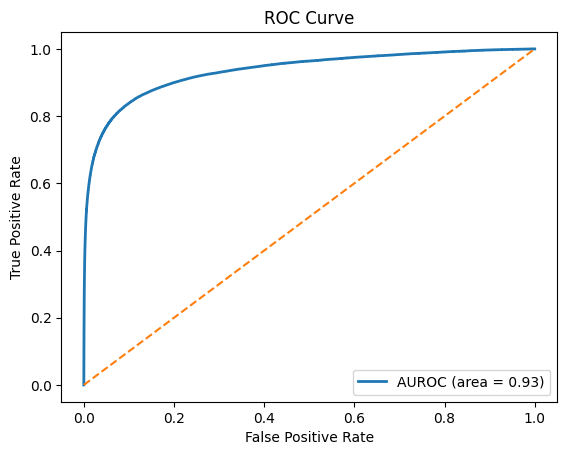

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Flatten if multilabel
y_true = Y_test_new.flatten()
y_scores = np.maximum(np.copy(recc_preds), np.copy(plm_preds)).flatten()   # RAW predictions (no threshold)

# AUROC
auroc = roc_auc_score(y_true.astype(None), y_scores)
print(f'AUROC: {auroc:.3f}')

fprs, tprs, _ = roc_curve(y_true.astype(None), y_scores)

plt.figure()
plt.plot(fprs, tprs, lw=2, label=f'AUROC (area = {auroc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.savefig('auroc.pdf')